In [2]:
import pandas as pd 
import numpy as np 

# Modeling Results

## Basic Features results

We have 20000 samples from 10 subjects(each has 2000 samples) and 240 features. We split them into 80%(16,000) and 20%(4,000) train and test data.

In [5]:
data=np.load('wavelet_outputs/all_subjects_wavelet_features_db4_L5.npz',allow_pickle=True)
X=data['X_features']
y=data['y_labels']
print(X.shape)
print(y.shape)
print(np.bincount(y))

(20000, 240)
(20000,)
[2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]


### Train Test Split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(16000, 240) (4000, 240)
(16000,) (4000,)


We fit them into three models, using random forest as the baseline model, as well as SVM and Logistic regression

### Random Forest

RF Accuracy: 0.71025


<Figure size 800x800 with 0 Axes>

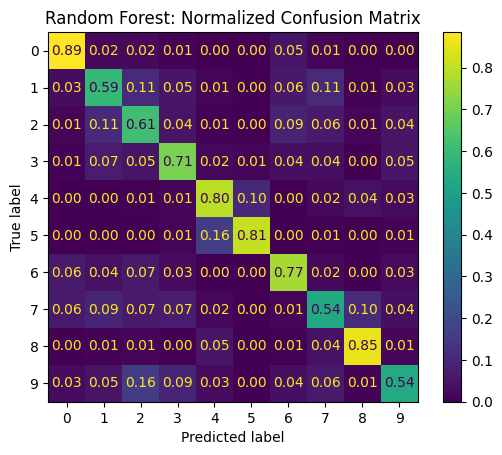

              precision    recall  f1-score   support

           0       0.81      0.89      0.84       400
           1       0.61      0.59      0.60       400
           2       0.56      0.61      0.59       400
           3       0.69      0.71      0.70       400
           4       0.73      0.80      0.76       400
           5       0.88      0.81      0.84       400
           6       0.73      0.77      0.74       400
           7       0.59      0.54      0.56       400
           8       0.83      0.85      0.84       400
           9       0.69      0.54      0.61       400

    accuracy                           0.71      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.71      0.71      4000



In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay,confusion_matrix
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf=accuracy_score(y_test, y_pred_rf)

print("RF Accuracy:", acc_rf)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8,8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    normalize="true",  
    values_format=".2f"
)

plt.title("Random Forest: Normalized Confusion Matrix")
plt.show()
print(classification_report(y_test,y_pred_rf))

### SVM

SVM Accuracy: 0.8205


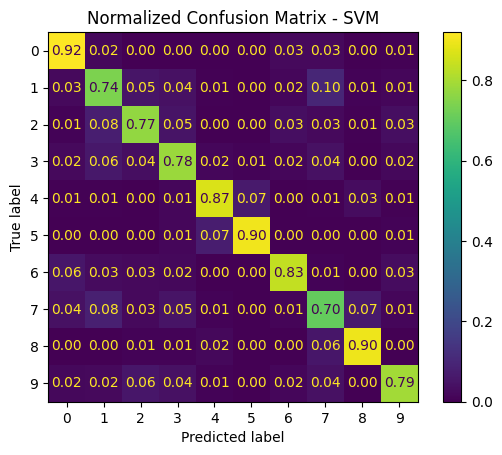

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       400
           1       0.71      0.74      0.73       400
           2       0.79      0.77      0.78       400
           3       0.76      0.78      0.77       400
           4       0.87      0.87      0.87       400
           5       0.92      0.90      0.91       400
           6       0.87      0.83      0.85       400
           7       0.70      0.70      0.70       400
           8       0.89      0.90      0.89       400
           9       0.86      0.79      0.82       400

    accuracy                           0.82      4000
   macro avg       0.82      0.82      0.82      4000
weighted avg       0.82      0.82      0.82      4000



In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", random_state=42)
)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
acc_svm=accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    normalize="true",
    values_format=".2f"
)
plt.title("Normalized Confusion Matrix - SVM")
plt.show()
print(classification_report(y_test, y_pred_svm))

### Logistic Regression

Logistic Regression Accuracy: 0.8915


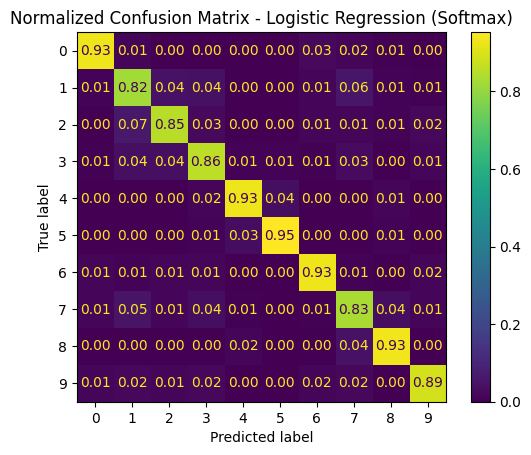

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       400
           1       0.81      0.82      0.81       400
           2       0.87      0.85      0.86       400
           3       0.84      0.86      0.85       400
           4       0.93      0.93      0.93       400
           5       0.95      0.95      0.95       400
           6       0.92      0.93      0.93       400
           7       0.81      0.83      0.82       400
           8       0.92      0.93      0.93       400
           9       0.92      0.89      0.90       400

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        # multi_class="multinomial", 
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    )
)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr=accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",acc_lr)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    normalize="true",
    values_format=".2f"
)
plt.title("Normalized Confusion Matrix - Logistic Regression (Softmax)")
plt.show()
print(classification_report(y_test, y_pred_lr))

In [10]:
results={'Random Forest':acc_rf,'SVM':acc_svm,'Logistic Regression':acc_lr}
accuracy_comparison = pd.DataFrame({
    "Algorithm": results.keys(),
    "Accuracy": results.values()
})
print(accuracy_comparison)
print(f'Average accuracy is',accuracy_comparison['Accuracy'].mean())

             Algorithm  Accuracy
0        Random Forest   0.71025
1                  SVM   0.82050
2  Logistic Regression   0.89150
Average accuracy is 0.8074166666666667


# Features Vs. Average Features

# Animals Vs. Objects

# Random Pooled Results

In [12]:
scaler = lr_model.named_steps['standardscaler']
clf = lr_model.named_steps['logisticregression']
print("Scaler mean shape:", scaler.mean_.shape)       # (240,)
print("Scaler scale shape:", scaler.scale_.shape)     # (240,)
print("Coefficient matrix shape:", clf.coef_.shape)   # (10, 240)
print("Intercept shape:", clf.intercept_.shape)       # (10,)

Scaler mean shape: (240,)
Scaler scale shape: (240,)
Coefficient matrix shape: (10, 240)
Intercept shape: (10,)


In [13]:
y_prob = lr_model.predict_proba(X_test)
print(y_prob.shape)   # (4000, 10)
print(y_prob[0])
print("Predicted class:", np.argmax(y_prob[0]))
print("True class:", y_test[0])

(4000, 10)
[8.13869291e-04 2.87334821e-03 4.83694908e-05 5.15429122e-06
 2.31292560e-11 5.72918890e-13 2.78795608e-02 8.22560703e-05
 7.89730288e-09 9.68297434e-01]
Predicted class: 9
True class: 6


In [14]:
cm = confusion_matrix(y_test, y_pred_lr, normalize="true")
print(cm)

[[0.93   0.0125 0.0025 0.0025 0.     0.0025 0.025  0.0175 0.005  0.0025]
 [0.0075 0.82   0.045  0.0425 0.0025 0.     0.0125 0.0575 0.0075 0.005 ]
 [0.0025 0.065  0.85   0.025  0.0025 0.     0.0125 0.0125 0.01   0.02  ]
 [0.005  0.0375 0.0375 0.8575 0.01   0.0075 0.005  0.0275 0.     0.0125]
 [0.     0.     0.0025 0.0175 0.9275 0.035  0.     0.0025 0.0125 0.0025]
 [0.     0.     0.     0.0075 0.03   0.9525 0.     0.     0.0075 0.0025]
 [0.0125 0.0075 0.0125 0.015  0.     0.     0.9275 0.0075 0.     0.0175]
 [0.0125 0.05   0.015  0.035  0.005  0.     0.005  0.83   0.035  0.0125]
 [0.     0.0025 0.0025 0.     0.0175 0.     0.     0.045  0.9325 0.    ]
 [0.015  0.02   0.015  0.02   0.0025 0.     0.0175 0.02   0.0025 0.8875]]


In [15]:
layout = data['layout']

for cls in range(clf.coef_.shape[0]):
    w = clf.coef_[cls]
    top_idx = np.argsort(np.abs(w))[-10:][::-1]
    
    print(f"\nTop features for subject {cls}:")
    for idx in top_idx:
        ch, band, feat, col = layout[idx]
        print(f"  weight={w[idx]: .4f} | col={col} | {ch}-{band}-{feat}")


Top features for subject 0:
  weight= 3.0521 | col=156 | PO7-D5-log_energy
  weight= 2.6628 | col=188 | PO8-D5-std
  weight= 2.3855 | col=227 | POz-D3-mean
  weight= 2.3447 | col=151 | PO7-A5-log_energy
  weight=-2.3339 | col=65 | O2-D5-energy
  weight= 2.3168 | col=186 | PO8-D5-log_energy
  weight= 2.1386 | col=111 | PO3-D2-log_energy
  weight= 2.0605 | col=185 | PO8-D5-energy
  weight= 2.0446 | col=158 | PO7-D5-std
  weight= 1.9768 | col=106 | PO3-D3-log_energy

Top features for subject 1:
  weight= 2.0773 | col=157 | PO7-D5-mean
  weight=-2.0584 | col=215 | POz-D5-energy
  weight= 1.7582 | col=152 | PO7-A5-mean
  weight=-1.5142 | col=36 | Oz-D5-log_energy
  weight=-1.4800 | col=67 | O2-D5-mean
  weight= 1.3480 | col=167 | PO7-D3-mean
  weight= 1.3345 | col=231 | POz-D2-log_energy
  weight= 1.2877 | col=172 | PO7-D2-mean
  weight= 1.2824 | col=98 | PO3-D5-std
  weight=-1.2817 | col=52 | Oz-D2-mean

Top features for subject 2:
  weight= 4.0974 | col=63 | O2-A5-std
  weight= 2.6266 | 

### Observation 1 — Subject Identity is Concentrated in Posterior Visual Electrodes

Inspection of the Logistic Regression coefficients shows that the most influential features are consistently located in **posterior occipital and parieto-occipital electrodes**, including:

- `O1`, `O2`, `Oz`
- `PO3`, `PO4`
- `PO7`, `PO8`
- `POz`

These electrodes lie over the **visual cortex**, which is the primary region responsible for processing the visual stimuli used in the experiment.

The model rarely relies on features outside this posterior region, indicating that subject discrimination is driven primarily by **visual cortical activity patterns** rather than by distributed noise or unrelated signals across the scalp.

This spatial pattern provides strong biological plausibility: since the experiment involves visually evoked responses, individual differences in the **visual processing network** appear to encode distinctive neural signatures that allow subjects to be separated by the classifier.

### Observation 2 — Identity Information is Dominated by Mid-Scale Wavelet Bands

Across subjects, the most important coefficients repeatedly appear in the following wavelet bands:

- **D5**
- **D4**
- **D3**

These bands correspond to **low-to-mid frequency oscillatory components** in the EEG signal after preprocessing.

Higher-frequency bands (such as `D1`) rarely appear among the most important features, suggesting that very high-frequency components contribute little to subject discrimination.

This indicates that subject identity is primarily encoded in **stable mid-frequency temporal dynamics** of the EEG signal rather than in high-frequency noise or transient artifacts.

The repeated appearance of D5–D3 across many subjects suggests that these bands capture meaningful structure in the neural response that is consistent within individuals but different across individuals.

### Observation 3 — Log-Energy, Mean, and Standard Deviation are the Most Informative Features

Among the five extracted statistics (`energy`, `log_energy`, `mean`, `std`, `entropy`), the Logistic Regression model most frequently assigns large coefficients to:

- **log_energy**
- **mean**
- **std**

This suggests that subject identity is primarily encoded through:

- the **overall magnitude of oscillatory activity** (`log_energy`)
- the **average signal level** (`mean`)
- the **variability of the signal** (`std`)

Raw `energy` and `entropy` features appear less frequently among the highest-weight coefficients.

The prominence of `log_energy` is particularly notable, since the logarithmic transform stabilizes large dynamic ranges in power measurements and often improves separability between classes.

Overall, this pattern indicates that both **spectral power characteristics** and **distributional properties of the waveform** contribute to distinguishing subjects.

### Verifying the Most Important Logistic Regression Features

After inspecting the Logistic Regression coefficients, we identified several channel–band–feature combinations with large weights.

To better understand *why* these features are informative, we now examine how their values are distributed across subjects.

If a feature is truly useful for classification, we should observe that its values differ systematically between subjects. In other words, the feature distribution for one subject should be shifted relative to others.

To test this, we will:

1. Identify the **globally most important features** based on the magnitude of Logistic Regression coefficients.
2. Visualize their **distribution across subjects** using boxplots.
3. Confirm whether these features show clear subject-specific separation.

This step connects the model's learned parameters back to the underlying EEG feature space and helps interpret which neural characteristics distinguish individuals.

In [16]:
# Identify globally important features from Logistic Regression

scaler = lr_model.named_steps["standardscaler"]
clf = lr_model.named_steps["logisticregression"]

layout = data["layout"]

# Average absolute coefficient across all classes
global_importance = np.mean(np.abs(clf.coef_), axis=0)

# Get top features
top_k = 10
top_indices = np.argsort(global_importance)[-top_k:][::-1]

print("Top globally important features:")
for idx in top_indices:
    ch, band, feat, col = layout[idx]
    print(f"importance={global_importance[idx]:.4f} | col={col} | {ch}-{band}-{feat}")

Top globally important features:
importance=1.5516 | col=47 | Oz-D3-mean
importance=1.4849 | col=37 | Oz-D5-mean
importance=1.4547 | col=7 | O1-D5-mean
importance=1.4546 | col=36 | Oz-D5-log_energy
importance=1.3662 | col=157 | PO7-D5-mean
importance=1.2859 | col=6 | O1-D5-log_energy
importance=1.1826 | col=63 | O2-A5-std
importance=1.0901 | col=201 | PO8-D2-log_energy
importance=1.0857 | col=187 | PO8-D5-mean
importance=1.0413 | col=156 | PO7-D5-log_energy


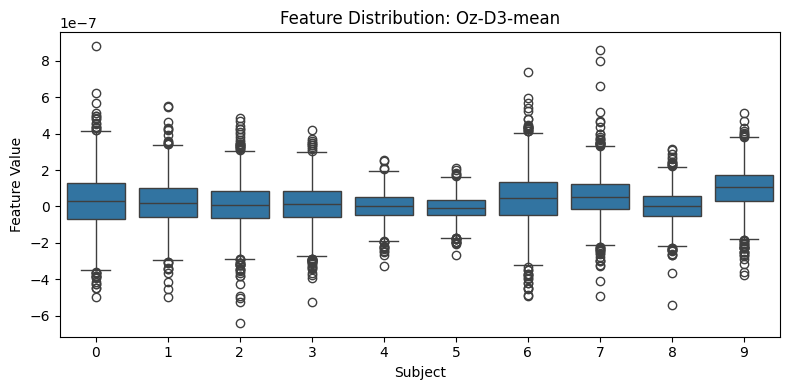

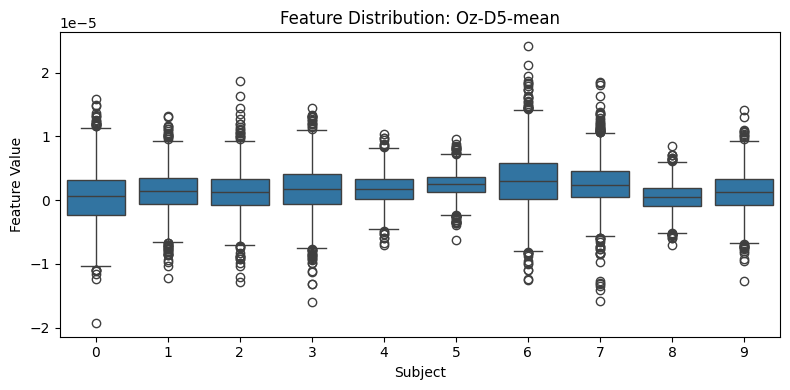

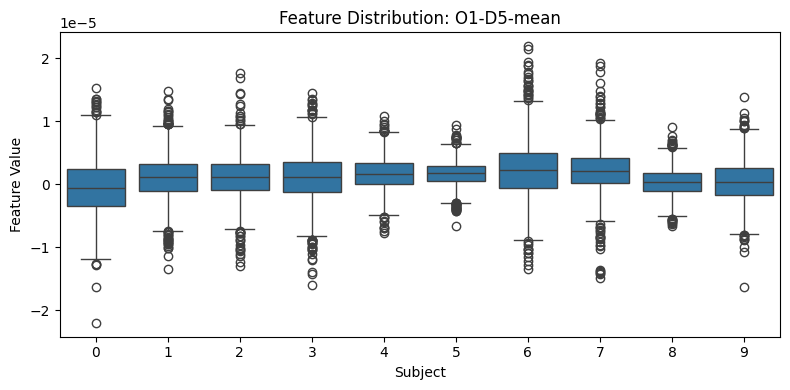

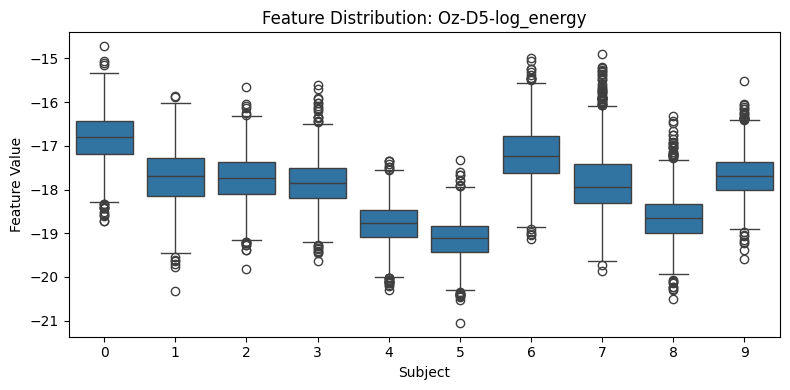

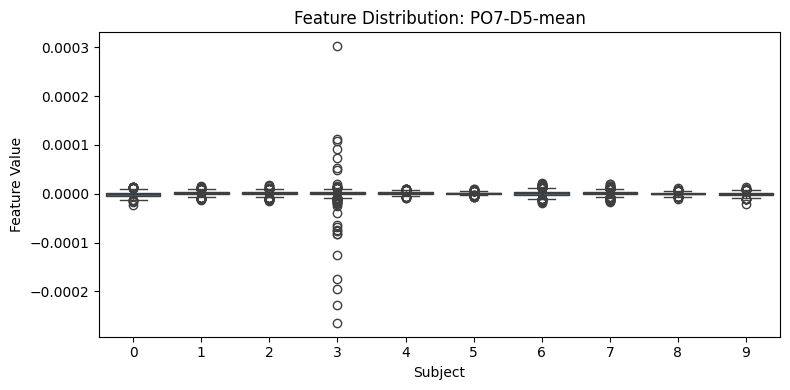

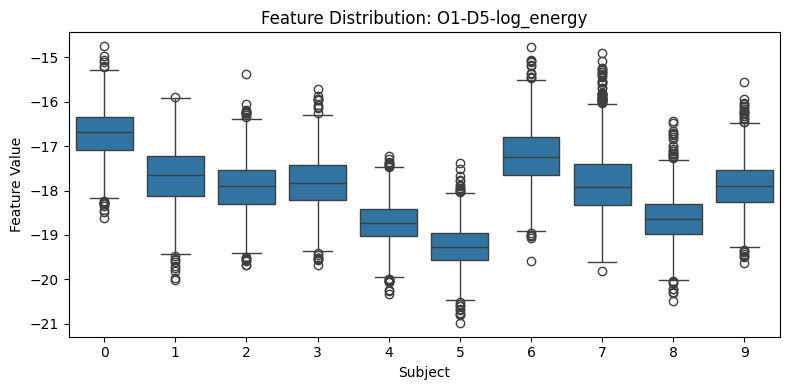

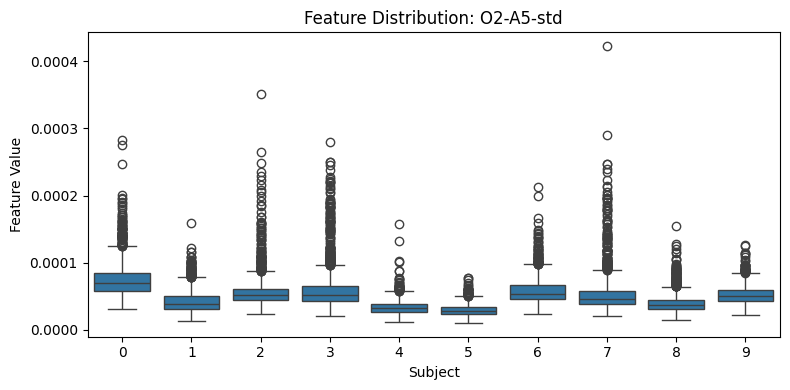

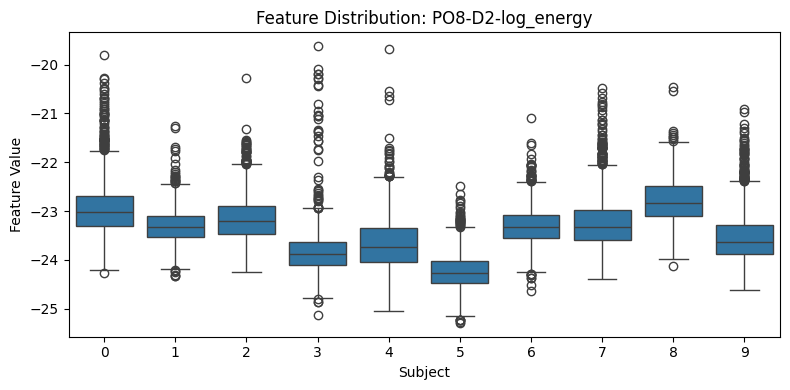

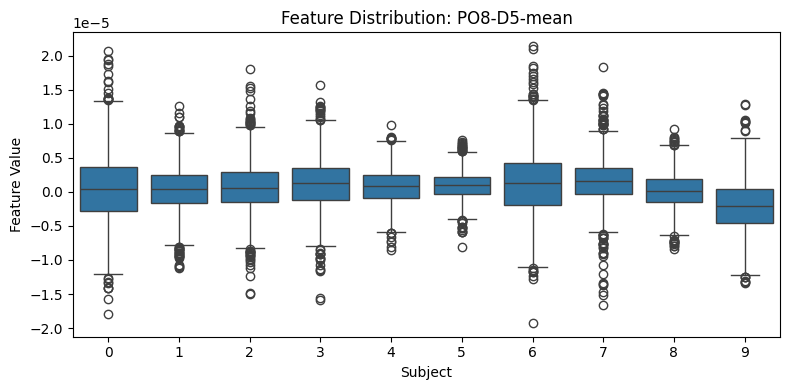

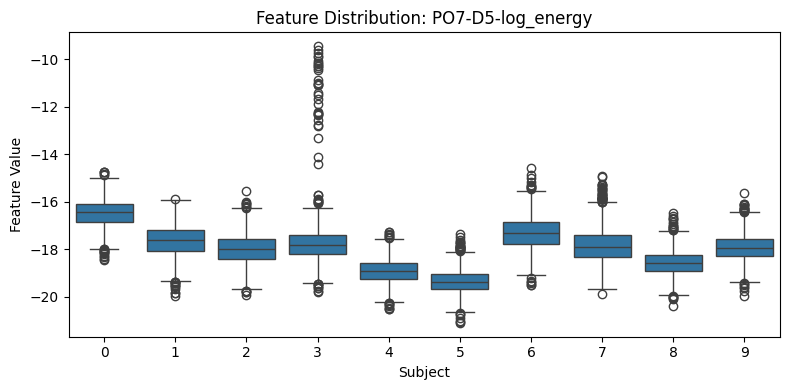

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Plot distributions for the most important features

for idx in top_indices:
    
    ch, band, feat, col = layout[idx]
    
    df_plot = pd.DataFrame({
        "value": X[:, idx],
        "subject": y.astype(str)
    })
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        data=df_plot,
        x="subject",
        y="value"
    )
    
    plt.title(f"Feature Distribution: {ch}-{band}-{feat}")
    plt.xlabel("Subject")
    plt.ylabel("Feature Value")
    
    plt.tight_layout()
    plt.show()

### Visualizing Global Feature Importance as a Channel × Band Heatmap

To summarize the Logistic Regression model more compactly, we now aggregate the learned coefficients into a **channel × wavelet band heatmap**.

Rather than inspecting individual features one by one, this visualization answers a higher-level question:

> **Which electrodes and which wavelet bands contribute most strongly to subject identification overall?**

To do this, we average the absolute Logistic Regression coefficients across all subjects and then group them by:

- **channel** (e.g., `O1`, `Oz`, `PO7`)
- **wavelet band** (e.g., `A5`, `D5`, `D4`, `D3`, `D2`, `D1`)

This produces a spatial–spectral summary of the classifier’s behavior.

If the earlier coefficient analysis is correct, we expect the heatmap to show strongest importance in:

- **posterior visual electrodes**
- **mid-scale bands such as D5, D4, and D3**

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Access fitted logistic regression and metadata
scaler = lr_model.named_steps["standardscaler"]
clf = lr_model.named_steps["logisticregression"]
layout = data["layout"]

# Mean absolute coefficient across classes
global_importance = np.mean(np.abs(clf.coef_), axis=0)

# Build long-format table
rows = []
for idx, imp in enumerate(global_importance):
    ch, band, feat, col = layout[idx]
    rows.append({
        "channel": ch,
        "band": band,
        "feature": feat,
        "importance": imp
    })

imp_df = pd.DataFrame(rows)
imp_df.head()

,channel,band,feature,importance
0,O1,A5,energy,0.392719
1,O1,A5,log_energy,0.814585
2,O1,A5,mean,0.184156
3,O1,A5,std,0.615200
4,O1,A5,entropy,0.133834


In [19]:
# Aggregate over feature type to get channel x band importance
band_heatmap_df = (
    imp_df.groupby(["channel", "band"])["importance"]
    .mean()
    .reset_index()
)

# Keep channels/bands in a sensible order
channel_order = list(data["ch_names"])
band_order = list(data["band_names"])

heatmap_mat = band_heatmap_df.pivot(
    index="channel",
    columns="band",
    values="importance"
).reindex(index=channel_order, columns=band_order)

print(heatmap_mat)

band           A5        D5        D4        D3        D2        D1
channel                                                            
O1       0.428099  0.909950  0.440760  0.445167  0.516443  0.288620
Oz       0.581604  0.944873  0.633568  0.711919  0.630656  0.326124
O2       0.610900  0.742055  0.523428  0.521323  0.554882  0.357330
PO3      0.426787  0.565535  0.540250  0.469239  0.454868  0.284901
PO4      0.437822  0.685660  0.319394  0.421353  0.478308  0.324197
PO7      0.514877  0.682465  0.325695  0.364267  0.489980  0.283325
PO8      0.384915  0.764509  0.413155  0.414333  0.620457  0.269608
POz      0.402586  0.570809  0.464724  0.447548  0.591292  0.302244


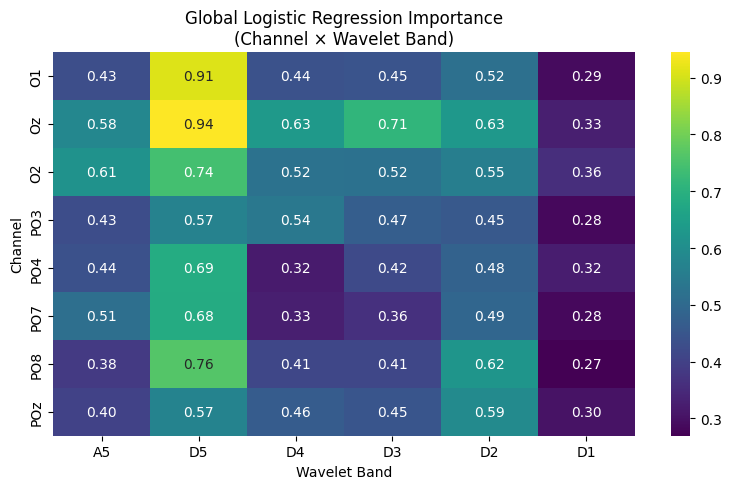

In [21]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_mat,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)
plt.title("Global Logistic Regression Importance\n(Channel × Wavelet Band)")
plt.xlabel("Wavelet Band")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

To interpret the Logistic Regression model, we visualized the average magnitude of learned coefficients across channels and wavelet bands. The resulting heatmap revealed that the classifier relies primarily on posterior occipital electrodes (O1, Oz, O2) and mid-scale wavelet bands (D5–D3). These regions correspond to the visual cortex, which is strongly engaged by the visual stimuli used in the experiment. The dominance of these bands suggests that subject-specific neural signatures are encoded in stable mid-frequency temporal dynamics of visual cortical activity. This explains why a linear classifier can successfully distinguish individuals using the extracted wavelet features.

### Feature-Type Importance in Logistic Regression

Each wavelet band was summarized using five statistical features:

- `energy`
- `log_energy`
- `mean`
- `std`
- `entropy`

To better understand how the Logistic Regression classifier distinguishes subjects, we analyze which **feature types contribute most strongly to the model.

We compute the average absolute coefficient magnitude across all subjects and aggregate them by feature type.

This reveals which statistical properties of the EEG signal carry the most discriminative information for subject identification.

In [22]:
# Compute importance grouped by feature type

rows = []

for idx, imp in enumerate(global_importance):
    ch, band, feat, col = layout[idx]
    rows.append({
        "channel": ch,
        "band": band,
        "feature_type": feat,
        "importance": imp
    })

feat_df = pd.DataFrame(rows)

feature_type_importance = (
    feat_df.groupby("feature_type")["importance"]
    .mean()
    .sort_values(ascending=False)
)

print(feature_type_importance)

feature_type
log_energy    0.672654
mean          0.615214
std           0.535837
energy        0.449514
entropy       0.214572
Name: importance, dtype: float64


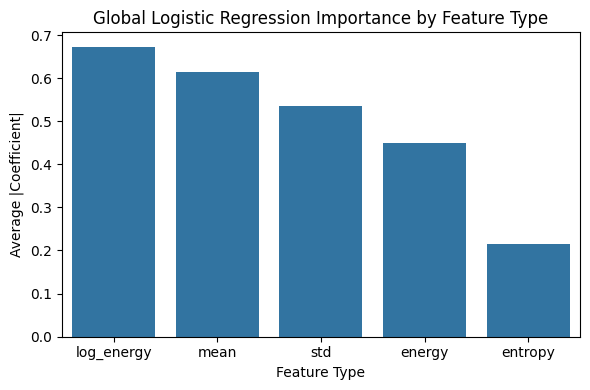

In [23]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=feature_type_importance.index,
    y=feature_type_importance.values,
)

plt.title("Global Logistic Regression Importance by Feature Type")
plt.xlabel("Feature Type")
plt.ylabel("Average |Coefficient|")

plt.tight_layout()
plt.show()

Analysis of Logistic Regression coefficients shows that log_energy features are the most influential for subject classification, followed by waveform mean and std. This indicates that subject identity is primarily encoded in the magnitude and distribution of oscillatory activity rather than in signal complexity. Entropy features contribute relatively little, suggesting that waveform variability across individuals is better captured by power-based and amplitude-based statistics.

### Why Logistic Regression Win?

The Logistic Regression model performs well because the engineered wavelet features produce a structured feature space in which subjects are separated primarily by linear differences in posterior spatio-spectral statistics. Since these differences appear along consistent feature dimensions (e.g., Oz-D4 log-energy or PO7-D5 mean), a linear classifier can effectively distinguish subjects without requiring complex nonlinear decision boundaries.